

<div style="background: linear-gradient(120deg, #1ca9c9 0%, #40c4d6 60%, #7fe0e0 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Actividad 5: Comprensión de los Datos</h1>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Laboratorio de Procesamiento de Datos</h3>
    </div>
</div>



### Ejercicio 1. Taxonomía y calidad de datos: Palmer Penguins

**Dataset:** [Palmer Penguins CSV](https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv)

1. Carga el CSV y describe sus dimensiones, tipos, faltantes y duplicados.
2. Clasifica cada columna como nominal, ordinal, binaria, discreta o continua. Justifica cualquier caso discutible.
3. Calcula cardinalidad, proporción de cada categoría y moda para las variables categóricas.
4. Compara `species`, `island` y `sex` con tablas de frecuencia y gráficas apropiadas.
5. Analiza los faltantes de `sex`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Propón una estrategia, pero no la apliques sin justificarla.
6. Explica por qué `species` no debe codificarse como `1, 2, 3` si el modelo interpreta esos valores como cantidades.


--- Dimensiones ---
(344, 8)

--- Tipos de datos y Faltantes ---
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB
None

--- Duplicados ---
0

--- Variable: species ---
Cardinalidad: 3
Moda: Adelie
Proporción:
 species
Adelie       0.441860
Gentoo       0.360465
Chinstrap    0.197674
Name: proportion, dtype: float64

--- Variable: island ---
Cardinalidad: 3
Moda: Biscoe
Proporción:
 island
Biscoe       0.488372
Dre

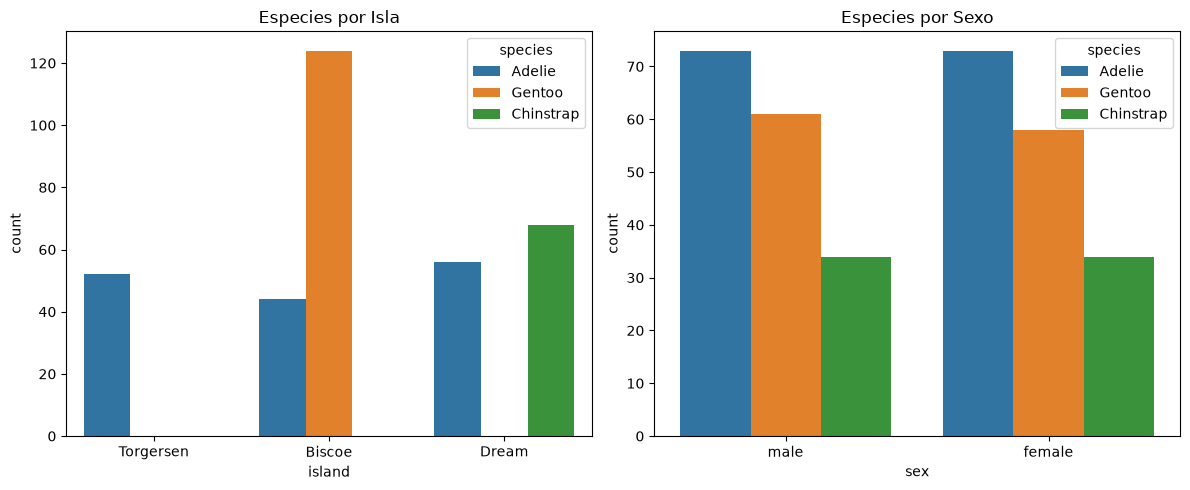


--- Faltantes por columna ---
sex                  11
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
dtype: int64


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carga del dataset y descripción general
url_penguins = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"
df_penguins = pd.read_csv(url_penguins)

print("--- Dimensiones ---")
print(df_penguins.shape)

print("\n--- Tipos de datos y Faltantes ---")
print(df_penguins.info())

print("\n--- Duplicados ---")
print(df_penguins.duplicated().sum())

# 3. Cardinalidad, proporción y moda (Variables categóricas)
cat_cols = ['species', 'island', 'sex']
for col in cat_cols:
    print(f"\n--- Variable: {col} ---")
    print(f"Cardinalidad: {df_penguins[col].nunique()}")
    print(f"Moda: {df_penguins[col].mode()[0]}")
    print("Proporción:\n", df_penguins[col].value_counts(normalize=True))

# 4. Tablas de frecuencia y gráficas
print("\n--- Tabla Cruzada: Especie vs Isla ---")
print(pd.crosstab(df_penguins['species'], df_penguins['island']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df_penguins, x='island', hue='species', ax=axes[0])
axes[0].set_title('Especies por Isla')
sns.countplot(data=df_penguins, x='sex', hue='species', ax=axes[1])
axes[1].set_title('Especies por Sexo')
plt.tight_layout()
plt.show()

# 5. Análisis de faltantes (Conteo)
print("\n--- Faltantes por columna ---")
print(df_penguins[['sex', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].isnull().sum())

2. Clasificación de variables:

species, island: Nominal. Categorías sin orden inherente.

sex: Binaria (o Nominal dicotómica). Dos categorías (Macho/Hembra).

bill_length_mm, bill_depth_mm, body_mass_g: Continua. Pueden tomar cualquier valor dentro de un rango (limitado únicamente por la precisión del instrumento de medición).

flipper_length_mm: Continua por naturaleza biológica, aunque en el dataset aparezca como números enteros (comportamiento discreto por la forma de medición en milímetros cerrados).

year: Ordinal / Discreta temporal.

5. Estrategia para faltantes:
Los registros que tienen NaN en las mediciones físicas (bill_length_mm, etc.) suelen faltar todos al mismo tiempo (mismos renglones). Dado que son muy pocos registros frente al total (aproximadamente 2 registros físicos y 11 de sexo), la estrategia ideal es la eliminación (Listwise Deletion). Imputar la media/mediana global alteraría la realidad biológica, ya que las medidas varían drásticamente entre especies e islas. Si se deseara imputar obligatoriamente, tendría que hacerse agrupando por species y sex.

6. Codificación de species (1, 2, 3):
Si asignas números enteros a clases nominales, los algoritmos matemáticos (como regresiones o redes neuronales) interpretarán que la especie "2" vale el doble que la especie "1", introduciendo un orden de magnitud y distancia inexistente. La forma correcta es usar One-Hot Encoding (variables dummy).

### Ejercicio 2. Distribuciones y transformación: propinas en restaurantes

**Dataset:** [Seaborn Tips CSV](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv)

1. Carga el dataset y describe las variables `total_bill`, `tip`, `size`, `day`, `time` y `smoker`.
2. Para `total_bill` y `tip`, calcula media, mediana, moda, desviación estándar, rango intercuartílico, asimetría y curtosis excedente.
3. Construye histogramas, diagramas de caja. Compara qué información aporta cada gráfico.
4. Compara la distribución de `total_bill` entre `time` y entre `day`. Usa estadísticas y visualizaciones.
5. Aplica una transformación logarítmica a `total_bill` y compara asimetría, histograma y gráfico Q-Q antes y después.
6. Explica por qué `size` debe analizarse como conteo discreto y no como una variable continua cualquiera.



--- Estadísticas para total_bill ---
Media: 19.79
Mediana: 17.80
Moda: 13.42
Desviación Estándar: 8.90
Rango Intercuartílico (IQR): 10.78
Asimetría (Skewness): 1.13
Curtosis: 1.22

--- Estadísticas para tip ---
Media: 3.00
Mediana: 2.90
Moda: 2.00
Desviación Estándar: 1.38
Rango Intercuartílico (IQR): 1.56
Asimetría (Skewness): 1.47
Curtosis: 3.65


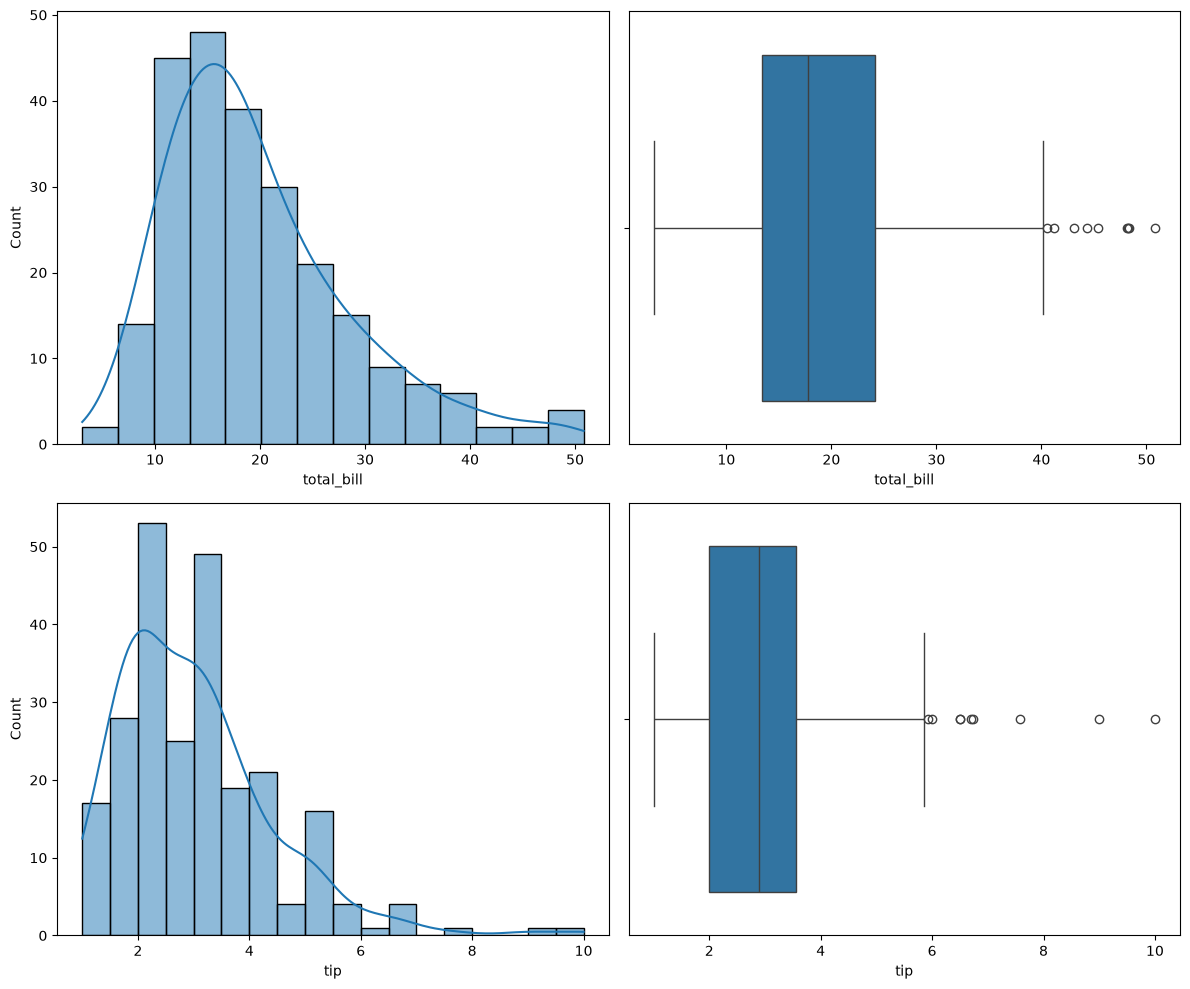

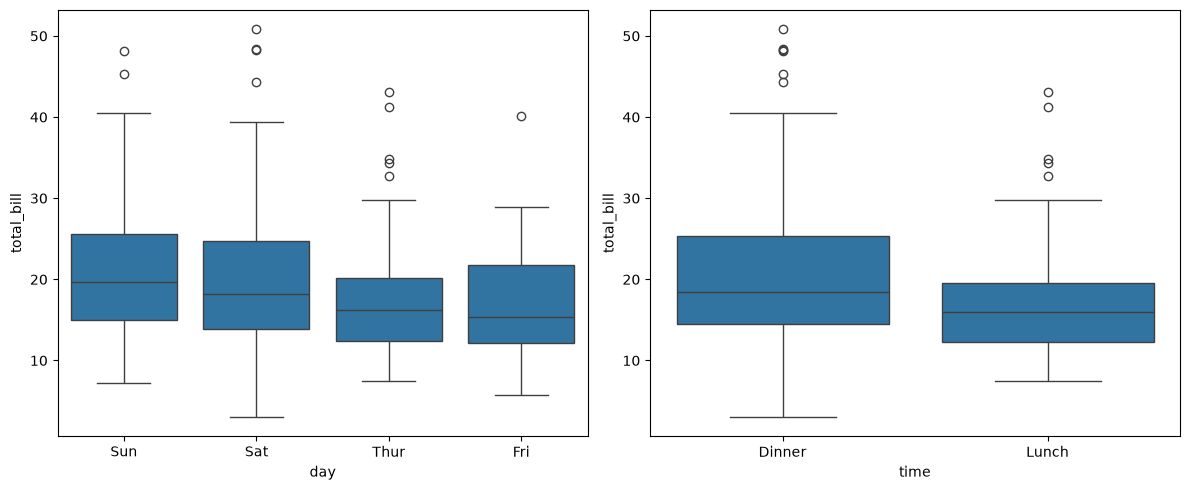


Asimetría original de total_bill: 1.13
Asimetría post-logaritmo: -0.12


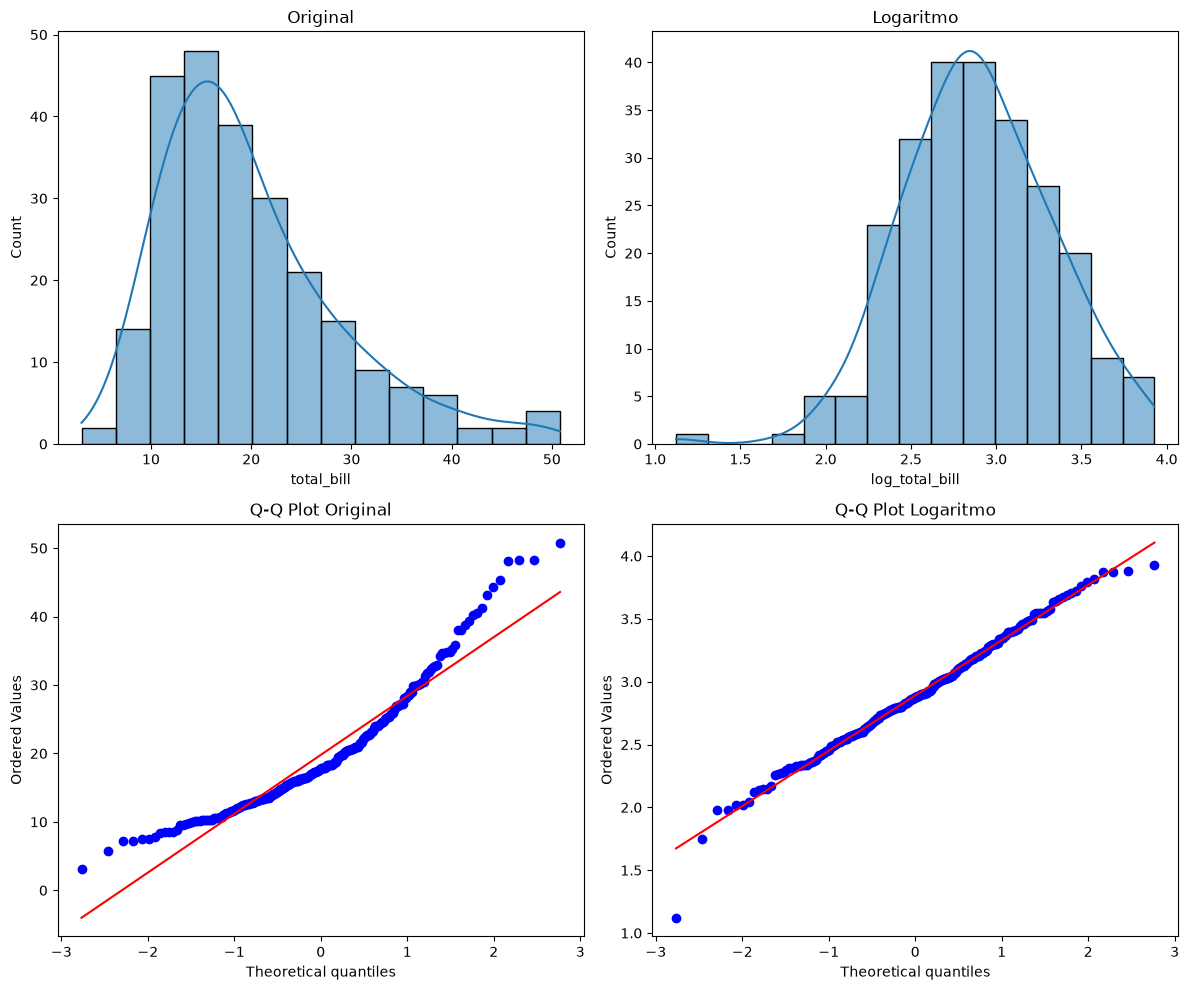

In [3]:
import scipy.stats as stats

# 1. Carga del dataset
url_tips = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df_tips = pd.read_csv(url_tips)

# 2. Estadísticas descriptivas para total_bill y tip
cols_num = ['total_bill', 'tip']

for col in cols_num:
    data = df_tips[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    print(f"\n--- Estadísticas para {col} ---")
    print(f"Media: {data.mean():.2f}")
    print(f"Mediana: {data.median():.2f}")
    print(f"Moda: {data.mode()[0]:.2f}")
    print(f"Desviación Estándar: {data.std():.2f}")
    print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
    print(f"Asimetría (Skewness): {data.skew():.2f}")
    print(f"Curtosis: {data.kurtosis():.2f}")

# 3. Histogramas y Diagramas de caja
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(df_tips['total_bill'], kde=True, ax=axes[0,0])
sns.boxplot(x=df_tips['total_bill'], ax=axes[0,1])
sns.histplot(df_tips['tip'], kde=True, ax=axes[1,0])
sns.boxplot(x=df_tips['tip'], ax=axes[1,1])
plt.tight_layout()
plt.show()

# 4. Comparación de total_bill vs time y day
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_tips, x='day', y='total_bill', ax=axes[0])
sns.boxplot(data=df_tips, x='time', y='total_bill', ax=axes[1])
plt.tight_layout()
plt.show()

# 5. Transformación logarítmica de total_bill
df_tips['log_total_bill'] = np.log(df_tips['total_bill'])
print(f"\nAsimetría original de total_bill: {df_tips['total_bill'].skew():.2f}")
print(f"Asimetría post-logaritmo: {df_tips['log_total_bill'].skew():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Histogramas antes y después
sns.histplot(df_tips['total_bill'], kde=True, ax=axes[0,0]).set_title('Original')
sns.histplot(df_tips['log_total_bill'], kde=True, ax=axes[0,1]).set_title('Logaritmo')
# Gráficos Q-Q
stats.probplot(df_tips['total_bill'], dist="norm", plot=axes[1,0])
axes[1,0].set_title("Q-Q Plot Original")
stats.probplot(df_tips['log_total_bill'], dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q Plot Logaritmo")
plt.tight_layout()
plt.show()

3. Histograma vs Diagrama de Caja:El histograma es ideal para ver la forma de la distribución (si está sesgada, si es bimodal y cómo se concentran las densidades). El diagrama de caja oculta la forma de la densidad subyacente, pero expone claramente los cuartiles ($Q_1, Q_2, Q_3$) y resalta matemáticamente los valores atípicos (outliers).

5. Efecto de la transformación Logarítmica:Originalmente, el gasto en restaurantes suele presentar asimetría positiva (cola larga hacia la derecha), ya que hay un límite inferior (cero) pero teóricamente ningún límite superior para grandes cuentas. Aplicar el logaritmo comprime los valores muy grandes, acercando la asimetría a 0. En los gráficos Q-Q se observa que, tras el logaritmo, los puntos se alinean mucho mejor con la recta teórica de la distribución normal, indicando una distribución más simétrica y estandarizable para modelos paramétricos.

6. Análisis de la variable size:Aunque son números, representan conteos de personas (comensales). Se trata de una variable cuantitativa discreta, no continua. No existe "1.5 comensales". Analizarla como continua usando densidades finas no tiene sentido físico; debe analizarse usando gráficos de barras discretos o matrices de frecuencias
